# A simple demonstration of how the Gaussian Consensus Hashing Duplicate Detection Algorithm works

## Quick Use

### 1. First lets load the relevant modules

In [1]:
from readysetgo.structure_clustering.global_descriptors.atomic_distances_descriptor import (
    AtomicDistancesDescriptor,
)
from readysetgo.structure_clustering.duplicate_detection_algorithms.hashing_duplicate_detection import (
    HashingDuplicateDetection,
)

import numpy as np
from ase.atoms import Atoms

### 2. Define an atoms list you wish to check for duplicates

In [ ]:
# lets create some functions to generate a list of  random structures


def create_base_structure(
    element: str = "C",
    number_of_atoms_per_structure: int = 3,
    box_cell_length: float = 3.0,
) -> Atoms:
    """Return an ASE Atoms object with a given number of atoms and box cell length.

    Args:
        element (str, optional): Element symbol. Defaults to "C".
        number_of_atoms_per_structure (int, optional): Number of atoms per structure. Defaults to 3.
        box_cell_length (float, optional): Cell length of unit cell in angstroms, used to define the cubic cell. Defaults to 3.0.
    """
    base_atoms = Atoms(
        f"{element}{number_of_atoms_per_structure}",
        positions=np.zeros((number_of_atoms_per_structure, 3)),
        cell=[box_cell_length, box_cell_length, box_cell_length],
    )

    return base_atoms


def create_random_structures(
    base_atoms: Atoms,
    structures_to_generate: int = 100,
    rng: np.random.Generator = np.random.default_rng(803),
) -> list[Atoms]:
    """Generate a list of ASE Atoms objects with random positions within a cubic box.

    Args:
        base_atoms (Atoms): Base ASE Atoms object to copy and modify.
        structures_to_generate (int, optional): Number of structures to generate. Defaults to 100.
        seed (int, optional): Random seed for reproducibility. Defaults to 803.
    """

    number_of_atoms_per_structure = len(base_atoms)
    if base_atoms.cell is None:
        base_atoms.set_cell([10.0, 10.0, 10.0])  # set a default cell if not defined

    cell_array = np.asarray(base_atoms.cell)
    random_position_list = (
        rng.random((structures_to_generate, number_of_atoms_per_structure, 3))
        * cell_array[0, 0]
    )

    atoms_list = []
    for pos in random_position_list:
        new_atoms = base_atoms.copy()
        new_atoms.positions = pos
        atoms_list.append(new_atoms)
    return atoms_list


# now lets make a list of 100 random structures with 3 carbon atoms in a 3x3x3 angstrom box
rng = np.random.default_rng(803)
base_structure = create_base_structure(
    element="C", number_of_atoms_per_structure=3, box_cell_length=3.0
)
atoms_list = create_random_structures(
    base_structure, structures_to_generate=100, rng=rng
)

### 3. Set Up duplicate detection algorithm and global descriptor

In [5]:
gd_object = (
    AtomicDistancesDescriptor()
)  # a simple global descriptor based on atomic distance distributions
gd_object.set_attribute(
    "dimensions", 128
)  # the number of bins in the distance histogram

dda_object = HashingDuplicateDetection(
    tolerance=0.01,  # we use an arbitrary tolerance of 0.01, we will demonstrate later how tune this value correctly
    atoms_list=atoms_list,
    global_descriptor_object=gd_object,
)  # ddas must have a tolerance and atoms_list specified
dda_object.set_attribute(
    "perturbations", 200
)  # the number of hashes used to generate a consensus
dda_object.set_attribute(
    "acceptance_rate", 0.5
)  # the threshold of hash consensus for determining whether a structure is unique

# for other DDAs you may need to set other attributes here, e.g. ClassicEuclideanAlgorithmC requires only the tolerance to be set. Make sure you import it if you wish to try it here.


### 4. Run the duplicate detection algorithm using the group function

In [ ]:
unique_structures = dda_object.detect_duplicates_in_atoms_list(
    reset_indexing=True
)  # on first call atoms indexing is done automatically so reset indexing not required


print(
    f"Found {unique_structures} unique structures out of {len(dda_object.atoms_list)} structures in the atoms list."
)

Found 100 unique structures out of 100 structures in the atoms list.


### 5. Now lets generate some dulplicate structures

In [ ]:
duplicate_indeces = rng.choice(range(len(atoms_list)), size=5, replace=False)
duplicate_atoms_list = [atoms_list[i].copy() for i in duplicate_indeces]


atoms_list_with_duplicates = atoms_list + duplicate_atoms_list

dda_object.set_attribute("atoms_list", atoms_list_with_duplicates)
# print(dda_object.global_descriptor_object.dimensions)
unique_structures = dda_object.detect_duplicates_in_atoms_list(
    reset_indexing=True
)  # because we use some duplicate structures, the meta data is also copied, so we need to reset the indexing and global descriptors to ensure the DDA is woring correctly
print(
    f"Found {unique_structures} unique structures and {len(dda_object.atoms_list) - unique_structures} duplicate structures in the atoms list."
)

Found 100 unique structures and 5 duplicate structures in the atoms list.


### 6. Instead of using exact duplicates, what about slight variations of the same structure

In [9]:
near_duplicate_atoms_list = []
for atoms in duplicate_atoms_list:
    new_atoms = atoms.copy()
    new_atoms.rattle(0.0004)  # add a small random displacement to each atom

    # remember to update the global descriptor after modifying the structure
    gd_object.set_attribute("structure", new_atoms)
    gd = gd_object.make_char_vec()
    new_atoms.info["global_descriptor"] = gd

    near_duplicate_atoms_list.append(new_atoms)

atoms_list_with_near_duplicates = atoms_list + near_duplicate_atoms_list

dda_object.set_attribute("atoms_list", atoms_list_with_near_duplicates)
unique_structures = dda_object.detect_duplicates_in_atoms_list(reset_indexing=True)
print(
    f"Found {unique_structures} unique structures and {len(dda_object.atoms_list) - unique_structures} duplicate structures in the atoms list."
)

Found 102 unique structures and 3 duplicate structures in the atoms list.


We observe that for a rattle of 0.0003 that two of the *near duplicate* atoms objects are considered the same and three are not. 

This may be a desirable outcome or maybe we would wish all of these values to the same, or all different. 

We can modify this by changing the **tolerance** value of the duplicate detection algorithm. 

However, it is often unclear for what to set this value to be we will describe the methods we use to tune our tolerance below

## Tuning the Tolerance

### 1. Import the tuning tolerance function

In [10]:
from readysetgo.structure_clustering.duplicate_detection_algorithms.utils.tune_tolerance import (
    tune_tolerance_value,
)

### 2. Create dummy dataset where we know how many target structures we should have

In [11]:
near_duplicates_per_structure = 5  # in real applications, this should be higher we use around 100 in our hashing algorithm paper
rattle_magnitude = 0.0001  #


The rattle magnitude here is the standard deviation of atomic positions

The rattle magnitude is the primary decision the user must make. 

Think about your system and how different of a structure should be considered "the same".

Some simple energy calculations on perturbed structures should give you an insight on this. 
<!-- For example a good place to start is to aim for a rattle that produces a standard deviation of 0.1 eV, the level of accuracy for a good DFT functional -->
<!-- If this is hard to think about one could approximate the standard deviation of positions to be the temperature with the following formula

$$
T=\frac{2\sigma}{3k_B}
$$

where $\sigma$ is our standard deviation of positions, or `rattle_magnitude` and $k_B$ is the Boltzmann constant

So for $\sigma = 0.001$, we can approximate the temperature at which such deformations would be typical, to be $T= -->

In [12]:
def generate_near_duplicates(
    atoms_list, near_duplicates_per_structure, rattle_magnitude
):
    tuning_atoms_list = []
    for atoms in atoms_list:
        for i in range(near_duplicates_per_structure):
            new_atoms = atoms.copy()
            new_atoms.rattle(
                rattle_magnitude, seed=803 + i
            )  # add a small random displacement to each atom
            # remember to update the global descriptor after modifying the structure
            gd_object.set_attribute("structure", new_atoms)
            gd = gd_object.make_char_vec()
            new_atoms.info["global_descriptor"] = gd
            tuning_atoms_list.append(new_atoms)
    return tuning_atoms_list


tuning_atoms_list = generate_near_duplicates(
    atoms_list, near_duplicates_per_structure, rattle_magnitude
)

### 3. Call the tune tolerance function

There is no 'correct' tolerance value. There are however tolerance values that give the result, or close to, the result we want. This is primarily for tuning, in a real case it is unlikely that structures will behave as well for you. 

To give yourself the best possible chance at choosing an appropriate tolerance value for your means we reccomend employing two binary searches. One to find the threshold at which a small increase in tolerance value will result in less structures than the target and one to find the threshold at which a small decrease in tolerance value will result in more structures than the target. Then take the average between them. 

This works best for clearly delineated individual structures where close to exact matches are desired by the user. 

In [ ]:
import matplotlib.pyplot as plt

print(len(tuning_atoms_list), "structures in tuning set")


def find_tolerance_values(
    tuning_atoms_list=tuning_atoms_list, target_structures=10, steps=10
):
    lower_target_tolerance = tune_tolerance_value(
        duplicate_detection_object=dda_object,
        tuning_atoms_list=tuning_atoms_list,
        target_structures=target_structures,
        bin_search_steps=steps,
        target_upper=False,  # returns the tolerance at the threshold where the number of predicted unique structures is more than target_structures
        verbose=1,
    )
    upper_target_tolerance = tune_tolerance_value(
        duplicate_detection_object=dda_object,
        tuning_atoms_list=tuning_atoms_list,
        target_structures=target_structures,
        bin_search_steps=steps,
        target_upper=True,  # returns the tolerance at the threshold where the number of predicted unique structures is less than target_structures
        verbose=1,
    )

    average_tolerance = (lower_target_tolerance + upper_target_tolerance) / 2
    return lower_target_tolerance, upper_target_tolerance, average_tolerance


lower_target_tolerance, upper_target_tolerance, average_tolerance = (
    find_tolerance_values(
        tuning_atoms_list=tuning_atoms_list, target_structures=len(atoms_list)
    )
)

# confirm the average tolerance returns the correct number of unique structures
dda_object.set_attribute("tolerance", average_tolerance)
unique_structures = dda_object.detect_duplicates_in_atoms_list(reset_indexing=True)
print(
    f"Threshold average tolerance: {average_tolerance} results in {unique_structures - len(atoms_list)} difference from target.."
)

500 structures in tuning set
Final tolerance: 0.009765625 with a difference of 0 from target structures (100) found
Final tolerance: 0.068359375 with a difference of 0 from target structures (100) found
Threshold average tolerance: 0.0390625 results in 0 difference from target..


We observe here that the 500 structures were clustered into 100 unique strucutres twice, the lower bound (tightest tolerance) was found to be around 0.013 and the upper bound (loosest tolerance) was found to be 0.082. To try and get as generalised a tolerance value as possible we take the average value between them (0.048) and check to ensure that this value also returns the target number of structures, in this case it does.

We plot the found unique structures below for fine grained scan of tolerances between the upper and lower tolerance values (with a small buffer either side to show what happens beyond our tolerance plateau)

In [ ]:
def create_tolerance_scan_data(
    lower_target_tolerance=lower_target_tolerance,
    upper_target_tolerance=upper_target_tolerance,
    buffer_fraction: float = 0.1,
    steps=10,
):
    between_tol_dict = {}
    buffer = buffer_fraction * (upper_target_tolerance - lower_target_tolerance)
    for tol in np.linspace(
        lower_target_tolerance - buffer, upper_target_tolerance + buffer, steps
    ):
        dda_object.set_attribute("tolerance", tol)
        unique_structures = dda_object.detect_duplicates_in_atoms_list(
            reset_indexing=False
        )
        between_tol_dict[tol] = unique_structures
    return between_tol_dict


between_tol_dict = create_tolerance_scan_data(
    lower_target_tolerance, upper_target_tolerance, steps=10
)

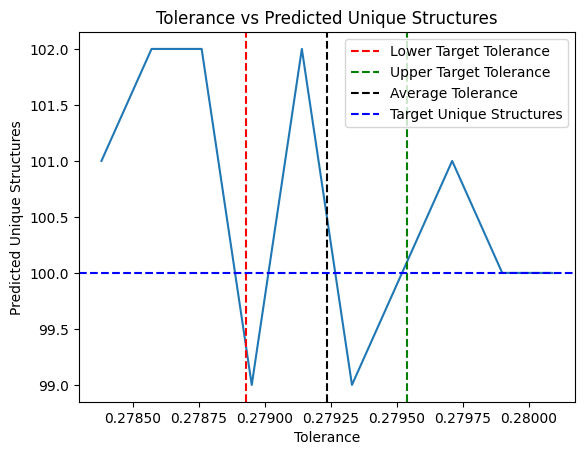

In [ ]:
def plot_tolerance_scan_data(
    between_tol_dict=between_tol_dict,
    lower_target_tolerance=lower_target_tolerance,
    upper_target_tolerance=upper_target_tolerance,
    average_tolerance=average_tolerance,
    target_structures=10,
):
    plt.plot(list(between_tol_dict.keys()), list(between_tol_dict.values()))
    plt.axvline(
        lower_target_tolerance,
        color="red",
        linestyle="--",
        label="Lower Target Tolerance",
    )
    plt.axvline(
        upper_target_tolerance,
        color="green",
        linestyle="--",
        label="Upper Target Tolerance",
    )
    plt.axvline(
        average_tolerance, color="black", linestyle="--", label="Average Tolerance"
    )
    plt.axhline(
        target_structures,
        color="blue",
        linestyle="--",
        label="Target Unique Structures",
    )
    # plt.yticks(
    #     np.arange(min(between_tol_dict.values()), max(between_tol_dict.values()) + 1, 1)
    # )
    plt.legend()
    plt.xlabel("Tolerance")
    plt.ylabel("Predicted Unique Structures")
    plt.title("Tolerance vs Predicted Unique Structures")
    plt.show()


plot_tolerance_scan_data(
    between_tol_dict,
    lower_target_tolerance,
    upper_target_tolerance,
    average_tolerance,
    target_structures=len(atoms_list),
)

From this plot we can observe that the average tolerance is a good estimated level as it returns the target number of structures and has a large buffer either side, meaning it will likely be able to catagorize new structures well (i.e. it is not over sensitive)

This is a good idealised case as the standard deviation of the global descriptor of 'perturbed' structure groups is much lower than the standard deviation of the global descriptors  for different structure groups. However when things get significantly noisier then it is less clear cut

In [ ]:
tuning_atoms_list = generate_near_duplicates(
    atoms_list,
    near_duplicates_per_structure,
    rattle_magnitude=0.01,  # increasing the rattle magnitude to demonstrate effect of noise our ability to select tolerance value
)
lower_target_tolerance, upper_target_tolerance, average_tolerance = (
    find_tolerance_values(
        tuning_atoms_list=tuning_atoms_list, target_structures=len(atoms_list), steps=15
    )
)
between_tol_dict = create_tolerance_scan_data(
    lower_target_tolerance, upper_target_tolerance, buffer_fraction=0.9, steps=10
)
plot_tolerance_scan_data(
    between_tol_dict,
    lower_target_tolerance,
    upper_target_tolerance,
    average_tolerance,
    target_structures=len(atoms_list),
)

Final tolerance: 0.2789306640625 with a difference of 0 from target structures (100) found
Final tolerance: 0.279541015625 with a difference of 0 from target structures (100) found


NameError: name 'plot_tolerance_scan_data' is not defined

Here it is apparent that there is no  significant plateau, take note of the x-axis scale, at the target number of unique structures. This likely means that the standard deviation of structural positions is high enough that it is impossible to properly group all structures in the atoms list to this number.

Some potential solutions to this are
1. reducing the rattle magnitude: only do this if it makes sense for your system
2. using a different global descriptor: it could be that the way you are representing your structure is poorly described by the global descriptor and therefore structures that should be classed as different are detected as duplicates, and vice versa
3. increasing the number of hashes: 200 should be sufficient as this is enough to get a reasonable sampling of a gaussian curve (see next section) but more hashes may improve the quality of your clustering

This should be a sufficient introduction to get started using this Gaussian Consensus Hashing. Furthermore, nothing presented here is specific to the Gaussian Consensus Hashing algorithm. You can run this entire tutorial again with a different duplicate detection algorithm such as `ClassicClusteringEuclideanAlgorithmC`

Next section we will dive in to how this algorithm actually works, so is unnecesary for those who are only interested in using it.

## Under the Hood of Gaussian Consensus Hashing

How does the Gaussian Consensus Hashing Duplicate Detection Algorithm Work?

In short, it is a flavour of random projection local sensitivity hashing that enable a 'soft' clustering of structures based on the similarity between global descriptors of structures. Its primary advantage is that the time required to check the similarity of a structure to a dataset scales independently of dataset size. It also demonstrates high-memory efficiency compared to its contempory similarity checking algorithms. 

### 1. Generate a structure with a global descriptor to demonstrate


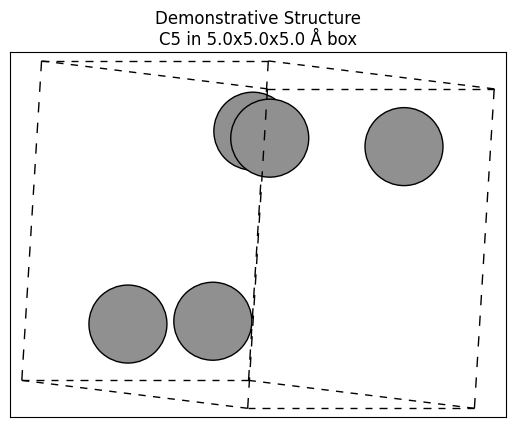

In [32]:
from pprint import pprint
from ase.visualize.plot import plot_atoms

demo_structure_elements = "C"
demo_structure_number_of_atoms = 5
demo_structure_box_cell_length = 5.0

base_structure = create_base_structure(
    element=demo_structure_elements,
    number_of_atoms_per_structure=demo_structure_number_of_atoms,
    box_cell_length=demo_structure_box_cell_length,
)

demo_structure = create_random_structures(
    base_structure, structures_to_generate=1, rng=rng
)[0]
plt.show()
fig, ax = plt.subplots()
plot_atoms(demo_structure, ax, radii=0.8, rotation=("0z,95x,45y"))
plt.title(
    f"Demonstrative Structure\n{demo_structure_elements}{demo_structure_number_of_atoms} in {demo_structure_box_cell_length}x{demo_structure_box_cell_length}x{demo_structure_box_cell_length} Å box"
)
ax.set_xticks([])
ax.set_yticks([])
plt.show()


Next we assign it a global descriptor (Using the atomic distances vector from before)

demonstrative global descriptor:
array([0.14510612, 0.21380024, 0.25844553, 0.34735022, 0.35833186,
       0.36447989, 0.41638043, 0.46106119, 0.48364547, 0.65307642])


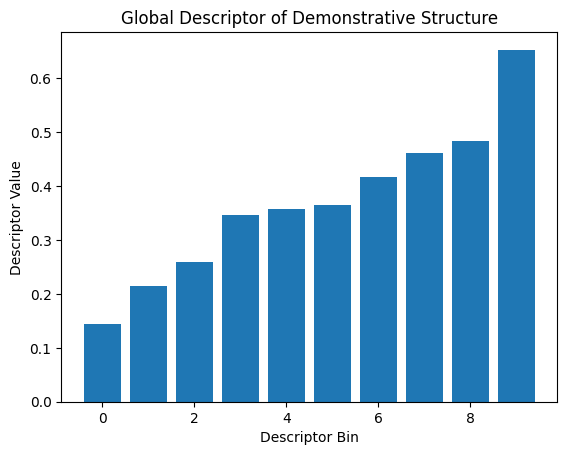

In [ ]:
gd_object.set_attribute("structure", demo_structure)
gd_object.set_attribute(
    "dimensions", int(np.floor((len(demo_structure) ** 2 - len(demo_structure)) / 2))
)  # We use the natural dimensions of the descriptor, as it is the strict upper triagle matrix this corresponds to (n^2-n)/2
gd = gd_object.make_char_vec()
demo_structure.info["global_descriptor"] = gd

# dda_object.set_attribute("atoms_list", [demo_structure])
print("demonstrative global descriptor:")
pprint(demo_structure.info["global_descriptor"])

plt.clf()
plt.bar(
    range(len(demo_structure.info["global_descriptor"])),
    demo_structure.info["global_descriptor"],
)
plt.xlabel("Descriptor Bin")
plt.ylabel("Descriptor Value")
plt.title("Global Descriptor of Demonstrative Structure")
plt.show()

dda_object.set_attribute("atoms_list", [demo_structure])

### 2. Setting up the *perturbation array*

This is one of the most core components of the algorithm. It requires two major input values

- Tolerance ($t$): this is the same value we tune in the previous section, it is used to control the spread of values in the normalization array. A higher, and therefore looser, tolerance will mean a greater spread of normalization values

- Perturbations ($N$): This determines the size fo the array, in principle a larger array will return a more precise detection function, however this is only up to a certain point and converges quickly once there are enough points to properly represent a Gaussian distribution

Without prior knowledge it may be unclear why we bother constructing a pertubation array. We demonstrate why later on but in short it allows us to 'soften' the forthcoming binary-like hashing step.

In [34]:
dda_object.set_attribute(
    "tolerance", 0.05
)  # we will take roughly the average value found from earlier for a low noise scenario
dda_object.set_attribute(
    "perturbations", 4
)  # more will be required for real applications


print("Perturbation array:")
pprint(dda_object.get_perturbation_array())

Perturbation array:
array([0.52488603, 0.46167581, 1.42404982, 1.31919993])


### 3. Perturb and round the global descriptor

Here we apply our perturbation array to our global descriptor. We firstly multiply the global descriptor by each value of the normalization array. This produces $N$ perturbed global descriptors. Next we round to the nearest value of $t$. 

To demonstrate the effect of this procedure we plot each $d_i$ for all $N$

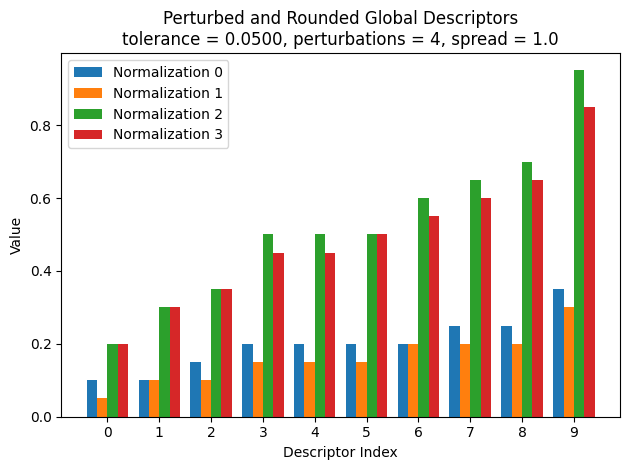

In [ ]:
perturbed_rounded = np.empty((dda_object.perturbations, gd_object.dimensions))


for i in range(dda_object.perturbations):
    # Perturb
    perturbed = (
        demo_structure.info["global_descriptor"]
        * dda_object.get_perturbation_array()[i]
    )
    # Round (this is typically the slowest step in the process so in the actual algorithm this is done in a more efficient way with numba)
    perturbed_rounded[i] = (
        np.round(perturbed / dda_object.tolerance) * dda_object.tolerance
    )

plt.clf()
x = np.arange(gd_object.dimensions)
width = 0.2

for i in range(dda_object.perturbations):
    plt.bar(x + i * width, perturbed_rounded[i], width, label=f"Normalization {i}")

plt.xlabel("Descriptor Index")
plt.ylabel("Value")
plt.title(
    f"Perturbed and Rounded Global Descriptors\ntolerance = {dda_object.tolerance:.4f}, perturbations = {dda_object.perturbations}, spread = {dda_object.spread}"
)
plt.xticks(x + width * 1.5, x)
plt.legend()
plt.tight_layout()
plt.show()

We observe that such a procedure results in producing $N$ similar but often distinct represenations of the global descriptor. This solves two problems.

1. Rounding errors: we need to round our vector values so there is a chance that they clash, sometimes a rounding can be marginal (e.g. 0.49 -> 0 vs 0.51 -> 1) and therefore lead to large differences in the hash. taking a consensus of slightly perturbed points mitigates this.
2. A degree of similarity: by genereating an Gaussian distribution of similar global descriptors for each strucutre, we can measure the similarity of two strucutres by how many of those global descriptors match

### 4. Building the Global Descriptor Array

The next step of this is to create a global descriptor array where each of the perturbed and rounded descriptors are embedded with a hash. To ensure consistent memory allocation we try to preinitialise the array with a target number of desired structures. 

We show explicitly how this is constructed here however the hash list can be automatically constructed using `get_input_global_descriptor` which includes performing all the prior steps

In [ ]:
hash_list = []
# reduced_dimensionality_fraction= 0.9

for i in range(len(perturbed_rounded)):
    # Convert to bytes and hash - this part stays in Python for compatibility
    hashed_descriptor = hash(perturbed_rounded[i].tobytes())
    hash_list.append(hashed_descriptor)

dda_object.reset_duplicate_detection(reset_indexing=True)
dda_object.preinitialise_global_descriptor_array(size=2)
dda_object.add_to_global_descriptor_array(
    dda_object.atoms_list[0], input_global_descriptor=np.array(hash_list)
)

print("Global Descriptor array:\n")
pprint(dda_object.global_descriptor_array)

Global Descriptor array:

array([[-2133658818672262706,                    0],
       [  871055533350157241,                    0],
       [-8646725966792074016,                    0],
       [  293153764547923860,                    0]])


You will notice that the first column of the array is now populated with hash values. We will now construct an abstraction of this array to allow us to easily detect duplicates, called the membership array.

### 5. Populating the global descriptor and memebership arrays



#### 5a. The three structure example

We initialise a hashing array of with three structures, two exact duplicates and one near duplicate.

We achieve this with the `add_new_atoms` function, which is the function called in the inner loop of the `group` function we used in the quick start demonstration.

In [ ]:
# Initialise a new structure and hashing array

similar_structure = demo_structure.copy()
different_structure = demo_structure.copy()
different_structure.rattle(0.08)  # large rattle to ensure difference

atoms_list = [demo_structure, similar_structure, different_structure]
dda_object.set_attribute("atoms_list", atoms_list)
dda_object.reset_duplicate_detection(reset_indexing=True)

dda_object.set_attribute(
    "perturbations", 4
)  # more will be required for real applications
dda_object.preinitialise_global_descriptor_array(
    size=3
)  # we know we are only adding 3 structures here

Lets first populate our global descriptor array

In [ ]:
for atoms in dda_object.atoms_list:
    dda_object.add_to_global_descriptor_array(atoms)

print("\nGlobal descripotr array after adding random structure:")
for i, vec in enumerate(dda_object.global_descriptor_array):
    vec_list = [int(x) for x in vec]
    print(f"Hash vector {i}: {vec_list}")


Global descripotr array after adding random structure:
Hash vector 0: [-2133658818672262706, -2133658818672262706, -2133658818672262706]
Hash vector 1: [871055533350157241, 871055533350157241, 5716140044250305196]
Hash vector 2: [-8646725966792074016, -8646725966792074016, -5032575900428769943]
Hash vector 3: [293153764547923860, 293153764547923860, -8423470673566702616]


We note that all hash vectors for each value of the array is the same for the first two columns

the third column is unique except for the first value. This is as expected. the first two columns are exact duplicates, whereas the third column is a rattled copy, we are able to capture the 'distance' between the structures like this.

To help us visualize and more easily assign similarity we construct a membership array. 

The memebership array is constructed witht the following rules
1. If the hash has not appeared previously in the hash vector it is assigned the atoms clustering id (typically its column of the membership array +1)
2. If the hash has appeared in the hash vector it is assigned the value of the clustering id of where the hash first appeared

In [50]:
for i, vec in enumerate(dda_object.membership_array):
    vec_list = [int(x) for x in vec]
    print(f"Membership of hashes in hash vector {i}: {vec_list}")

Membership of hashes in hash vector 0: [1, 1, 1]
Membership of hashes in hash vector 1: [1, 1, 3]
Membership of hashes in hash vector 2: [1, 1, 3]
Membership of hashes in hash vector 3: [1, 1, 3]


In the first hash vector all hashes are the same so they are assigned the clustering id of where the hash first appears which is the first structure. So they all get assigned the clustering id of 1. Below that the third, rattled structure has different hashes so gets assigned its own clustering id of 3.

This allows us to determine the uniqueness of each structure

In [ ]:
for i in range(len(dda_object.membership_array[0])):
    values, counts = np.unique(dda_object.membership_array[:, i], return_counts=True)
    clustering_id = i + 1
    counts_dict = dict(zip(values, counts))
    uniqueness = (
        counts_dict[clustering_id] / dda_object.perturbations
        if clustering_id in counts_dict
        else 0
    )
    # Convert counts to percentages (do not hardcode 4)
    percentages = (counts / dda_object.perturbations) * 100

    parts = [f"{int(v)}: {p:.0f}%" for v, p in zip(values, percentages)]

    print(
        f"structure {i + 1} character: ({', '.join(parts)}), Uniqueness: {uniqueness}"
    )


structure 1 character: (1: 100%), Uniqueness: 1.0
structure 2 character: (1: 100%), Uniqueness: 0
structure 3 character: (1: 25%, 3: 75%), Uniqueness: 0.75


We observe that 
- Structure 1 (`demo_structure`) is entirely unique as all hashes have not been seen before
- Structure 2 (`similar_structure`) is entirely not unique as all hashes have been seen brefore
- Structure 3 (`different_structure`) is 75% unique as only 3/4 of its hash values have not been seen before



#### 5b. The 10000 structure example

We can demonstrate how our DDA performs objectively by observing the number of unique structures found for increasing degrees of rattling on the same strucuture.
We create a dataset of 10000 structures of which it will be divided into batches of 500 with 20 levels of increasing positional standard deviation.



In [ ]:
from numpy import mean


dda_object.set_attribute(
    "perturbations", 4
)  # we will use a low number of normalizations for demonstration purposes, real applications will require more normalizations for better accuracy
dda_object.set_attribute(
    "tolerance", 0.1
)  # empirically derived value for this demonstration, this roughly corresponds to an expected unique value for a standard deviation of 1.0 in the rattle magnitude


def generate_rattle_dataset(
    structure: Atoms,
    levels: int = 20,
    batch_size: int = 500,
    step: float = 0.002,
    start: float = 0.0005,
) -> list[Atoms]:
    """
    Generate a dataset based on a single atoms object that varies the number of rattling. The scale, number of levels, step size and start positionof the rattle can be customized, as can the number of structures generated per rattle level

    Args:
        structure (Atoms): The ASE atoms object to base the dataset on, this will be the un-rattled structure.
        levels (int, optional): The number of different rattle magnitudes to generate. Defaults to 20.
        batch_size (int, optional): The number of structures to generate per rattle magnitude level. Defaults to 500.
        step (float, optional): The increment in rattle magnitude between levels. Defaults to 0.002.
        start (float, optional): The starting rattle magnitude. Defaults to 0.0005.

    Returns:
        list[Atoms]: A list of ASE Atoms objects with varying rattle magnitudes.
    """
    new_structure_list = []
    id = 0
    for i in range(levels):
        for j in range(batch_size):
            random_structure = structure.copy()
            random_structure.rattle(
                start + i * step, seed=803 + (i * 5 + j)
            )  # add a small random displacement to each atom
            gd_object.set_attribute("structure", random_structure)
            gd = gd_object.make_char_vec()
            random_structure.info["global_descriptor"] = gd
            random_structure.info["rattle_magnitude"] = start + i * step
            random_structure.info["id"] = id
            id += 1
            new_structure_list.append(random_structure.copy())
        # print(i, unique_per_rattle[i])
    return new_structure_list


random_structure_list = generate_rattle_dataset(
    demo_structure, 20, 500, step=0.05, start=0.005
)

rattle_magnitudes = sorted(
    set([s.info["rattle_magnitude"] for s in random_structure_list])
)


def unique_structures_per_rattle_magnitude(
    random_structure_list: list[Atoms], rattle_magnitudes: list[float]
) -> list:
    mean_unique_value_list = []

    for rattle_magnitude in rattle_magnitudes:
        rattle_structures = [
            s
            for s in random_structure_list
            if s.info["rattle_magnitude"] == rattle_magnitude
        ]
        all_structures = [demo_structure] + rattle_structures

        dda_object.set_attribute("atoms_list", all_structures)
        dda_object.reset_duplicate_detection(
            reset_indexing=True
        )  # reset the DDA for each rattle magnitude level
        dda_object.preinitialise_global_descriptor_array(size=len(all_structures))
        unique_structures = 0
        for structure in all_structures:
            input_global_descriptor = dda_object.get_input_global_descriptor(structure)
            unique_structures += dda_object.duplicate_check(
                structure, input_global_descriptor
            )
            dda_object.add_to_global_descriptor_array(
                structure, input_global_descriptor
            )
        # print(f"Unique structures found for rattle magnitude {rattle_magnitude:.4f}: {unique_structures:.2f}")
        mean_unique_value_list.append(unique_structures / len(rattle_structures))

    return mean_unique_value_list


mean_unique_value_list = unique_structures_per_rattle_magnitude(
    random_structure_list, rattle_magnitudes
)


20 rattle magnitudes tested


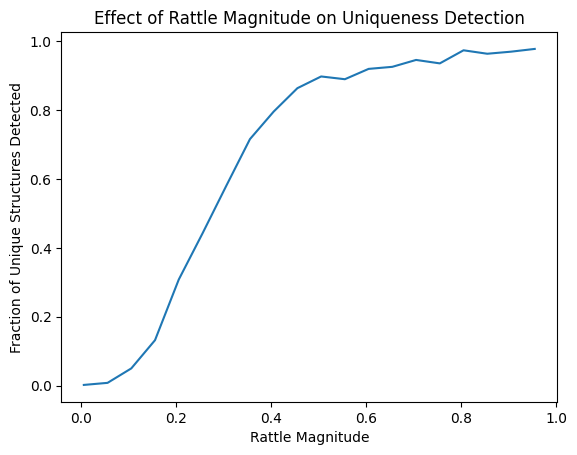

In [116]:
print(len(mean_unique_value_list), "rattle magnitudes tested")
plt.clf()
plt.plot(rattle_magnitudes, mean_unique_value_list)
plt.xlabel("Rattle Magnitude")
plt.ylabel("Fraction of Unique Structures Detected")
plt.title("Effect of Rattle Magnitude on Uniqueness Detection")
plt.show()


We can see that even with a very restricted model ($N=4$) and poor global descriptor (represented with $d=8$) that increasing the rattle magnitude correlates to increased uniqueness of structures found.

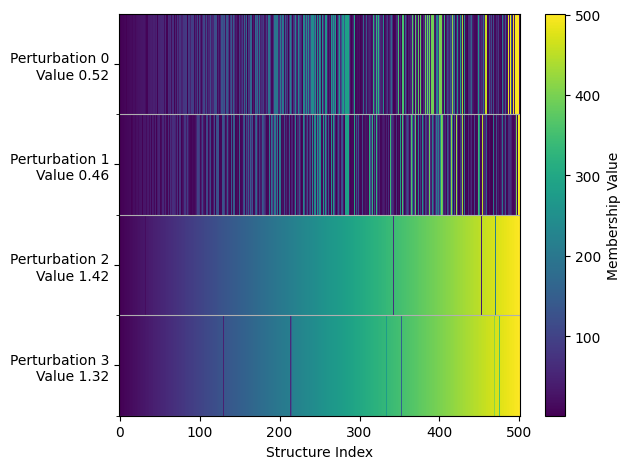

In [ ]:
# print("Global Descriptor array:\n", dda_object.global_descriptor_array)
plt.clf()
plt.imshow(
    dda_object.membership_array, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.ylabel("Perturbation")
plt.yticks(
    range(dda_object.perturbations),
    [
        f"Perturbation {i}\nValue {dda_object.get_perturbation_array()[i]:.2f}"
        for i in range(dda_object.perturbations)
    ],
)
plt.xlabel("Structure Index")
ax = plt.gca()
ax.set_yticks(np.arange(dda_object.perturbations) + 0.5, minor=True)
ax.grid(axis="y", which="minor", visible=True)
plt.colorbar(label="Membership Value")
plt.tight_layout()
plt.show()



The memebersip array shows how different perturbations influence how oftent they report matching hash value. Larger perturbation values match less than smaller ones.

### 6. Converging $N$ and the relationship to Euclidean Distance

We can converge $N$ using the same rattle increase method as above but for different values of $N$

In [ ]:
from tqdm import tqdm

n_rattle_dict = {}
N_list = [
    1,
    2,
    4,
    8,
    16,
    32,
    64,
    128,
    200,  # we include 200 here as this is the default value used in the paper
    256,
    # 512,
    # 1024,
    # 2048,
    # 4096,
    # 8192,
]  # for speed we don't run all these values (up to 1024 takes about 90s) unhash these if you wish to see a more thorough convergence


for i in tqdm(N_list):
    # set the tolerance value based on the highest rattle magnitude
    dda_object.set_attribute(
        "perturbations", i
    )  # reset to a default value before tuning
    highest_rattle_list = [
        s
        for s in random_structure_list
        if s.info["rattle_magnitude"] == rattle_magnitudes[-1]
    ]
    dda_object.set_attribute("perturbations", i)
    tol = tune_tolerance_value(
        dda_object,
        highest_rattle_list,
        target_structures=len(highest_rattle_list),
        bin_search_steps=20,
        target_upper=True,
        verbose=1,
    )
    dda_object.set_attribute("tolerance", tol)

    mean_unique_value_list = unique_structures_per_rattle_magnitude(
        random_structure_list, rattle_magnitudes
    )
    n_rattle_dict[dda_object.perturbations] = mean_unique_value_list

  0%|          | 0/10 [00:00<?, ?it/s]

Final tolerance: 0.025854110717773438 with a difference of 0 from target structures (500) found


 10%|█         | 1/10 [00:01<00:16,  1.86s/it]

Final tolerance: 0.03907203674316406 with a difference of 0 from target structures (500) found


 20%|██        | 2/10 [00:03<00:15,  1.98s/it]

...

 80%|████████  | 8/10 [00:57<00:25, 12.51s/it]

Final tolerance: 0.06452560424804688 with a difference of 0 from target structures (500) found


 90%|█████████ | 9/10 [01:34<00:20, 20.08s/it]

Final tolerance: 0.06076812744140625 with a difference of 0 from target structures (500) found


100%|██████████| 10/10 [02:20<00:00, 14.09s/it]


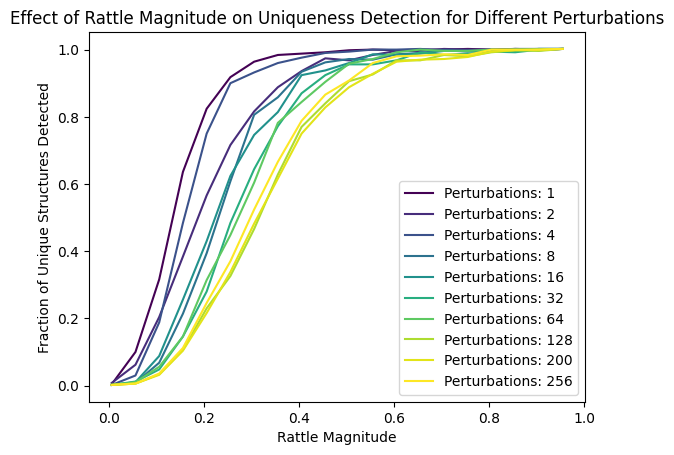

In [123]:
plt.clf()

for n_perturbations, unique_per_rattle in n_rattle_dict.items():
    plt.plot(
        rattle_magnitudes,
        unique_per_rattle,
        label=f"Perturbations: {n_perturbations}",
        color=plt.cm.viridis(np.log(n_perturbations) / np.log(max(N_list))),
    )

plt.xlabel("Rattle Magnitude")
plt.ylabel("Fraction of Unique Structures Detected")
plt.title(
    "Effect of Rattle Magnitude on Uniqueness Detection for Different Perturbations"
)
plt.legend()
plt.show()


Increaseing the number of perturbations seems to coverge towards the 256 value

Taking the RMSD of this plot compared to the the highest value of $N$ makes the trend more obvious

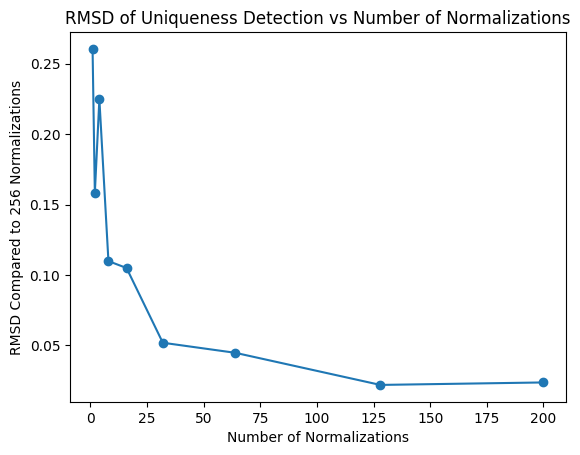

In [124]:
rmsd_compared_to_biggest = []
reference_unique_per_rattle = n_rattle_dict[N_list[-1]]
for n_normalizations, unique_per_rattle in n_rattle_dict.items():
    if n_normalizations == N_list[-1]:
        continue
    rmsd = np.sqrt(
        np.mean(
            (np.array(unique_per_rattle) - np.array(reference_unique_per_rattle)) ** 2
        )
    )
    rmsd_compared_to_biggest.append((n_normalizations, rmsd))


plt.clf()
n_values, rmsd_values = zip(*rmsd_compared_to_biggest)
plt.plot(n_values, rmsd_values, marker="o")
plt.xlabel("Number of Normalizations")
plt.ylabel(f"RMSD Compared to {N_list[-1]} Normalizations")
plt.title("RMSD of Uniqueness Detection vs Number of Normalizations")
plt.show()


We can see that increasing the number of perturbations results in a trend toward the $\max(N)$ limit. We cannot say that this is more accurate yet as we have not compared it to a ground truth. 

Let's compare our values to the Euclidean distances between the global descriptor of the orignal structure and that of the rattled ones. 

In [141]:
def calc_euclidean_distance(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Caculates the Euclidean distance between two vectors

    Args:
        vec1 (np.ndarray): first vector
        vec2 (np.ndarray): second vector

    Returns:
        float: Euclidean distance between vec1 and vec2
    """
    return np.sqrt(np.sum((vec1 - vec2) ** 2))


# generate dataset
gd_object.set_attribute("structure", demo_structure)
gd_object.set_attribute(
    "dimensions", int(np.floor((len(demo_structure) ** 2 - len(demo_structure)) / 2))
)
og_gd = gd_object.make_char_vec()


structure_list = generate_rattle_dataset(demo_structure, 30, 100, start=0.05, step=0.01)
rattle_magnitudes = sorted(set([s.info["rattle_magnitude"] for s in structure_list]))
# find the minimum tolerance that would cluster everything into a uniquely and use this as your base tolerance unit

# all_same_lower = tune_tolerance_value(
#         cluster_object=dda_object,
#         tuning_atoms_list=tuning_atoms_list,
#         target_structures=1,
#         bin_search_steps=20,
#         target_upper=False,
#         verbose=1,
#     )
N_list = [1, 16, 64, 200]
tol_list = []
for i in tqdm(N_list):
    highest_rattle_list = [
        s for s in structure_list if s.info["rattle_magnitude"] == rattle_magnitudes[-1]
    ]
    dda_object.set_attribute("perturbations", i)
    tol = tune_tolerance_value(
        dda_object,
        highest_rattle_list,
        target_structures=len(highest_rattle_list),
        bin_search_steps=20,
        target_upper=True,
        verbose=1,
    )
    tol_list.append(tol)


demo_structure.info["global_descriptor"] = og_gd


  0%|          | 0/4 [00:00<?, ?it/s]

Final tolerance: 0.007343292236328125 with a difference of 0 from target structures (100) found


 50%|█████     | 2/4 [00:00<00:00,  5.51it/s]

Final tolerance: 0.013751983642578125 with a difference of 0 from target structures (100) found


 75%|███████▌  | 3/4 [00:01<00:00,  1.96it/s]

Final tolerance: 0.013775825500488281 with a difference of 0 from target structures (100) found


100%|██████████| 4/4 [00:04<00:00,  1.06s/it]

Final tolerance: 0.01671314239501953 with a difference of 0 from target structures (100) found


In [142]:
results_array = np.zeros((len(structure_list), len(N_list) + 2))

# we artificially set an empirically derived tolerance of 0.5 for demonstration purpose, if using for difference structures you will need to tune this value as shown earlier
#
dda_object.set_attribute("perturbations", N_list[-1])
dda_object.set_attribute("spread", 0.1)
col_counter = 1
for i, N in enumerate(N_list[:]):
    # dda_object.set_attribute("normalizations", N)
    # hash_values, normalized_rounded = dda_object.get_hash_values(demo_structure)
    # print(normalized_rounded)
    dda_object.set_attribute("perturbations", N)
    dda_object.set_attribute("tolerance", tol_list[i])

    demo_input_global_descriptor = dda_object.get_input_global_descriptor(
        demo_structure
    )

    for index, atoms in enumerate(structure_list):
        dda_object.set_attribute("atoms_list", [demo_structure, atoms])
        dda_object.reset_duplicate_detection(reset_indexing=True)
        dda_object.preinitialise_global_descriptor_array(size=2)
        dda_object.add_to_global_descriptor_array(
            demo_structure, input_global_descriptor=demo_input_global_descriptor
        )
        dda_object.add_to_global_descriptor_array(
            atoms
        )  # input global descriptor is assigned automatically if not provided, but we provide it for the demo structure to ensure it is not modified by the process of adding the demo structure to the global descriptor array

        uniqueness = (
            len(dda_object.membership_array[dda_object.membership_array[:, -1] == 2])
            / N
        )  # the uniqueness vote is the mean of the membership values across all perturbations for the last structure (the one we are testing against the demo structure)
        results_array[index, col_counter] = uniqueness
    col_counter += 1


# get euclidean distances and rattle magnitudes
for index, atoms in enumerate(structure_list):
    results_array[index, 0] = calc_euclidean_distance(
        og_gd, atoms.info["global_descriptor"]
    )
    results_array[index, -1] = atoms.info["rattle_magnitude"]


<Figure size 640x480 with 0 Axes>

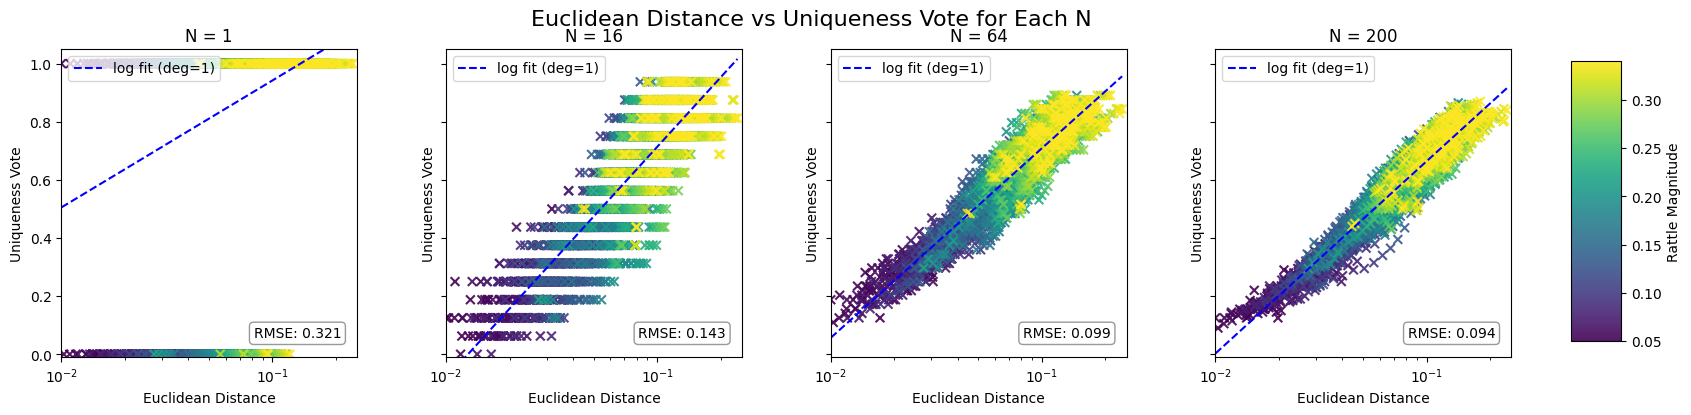

In [143]:
def smoothstep(x, edge0=0.0, edge1=1.0):
    """Cubic smoothstep: C1-continuous, flat slope at the ends."""
    # Normalize and clamp to [0, 1]
    x = np.clip((x - edge0) / (edge1 - edge0), 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


# Plot Euclidean Distance vs Uniqueness Vote for each N as individual subplots with colorbar to the right
plt.clf()

n_cols = len(N_list)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharex=True, sharey=True)
axes = axes.flatten()
idx = 0
for N in N_list:
    ax = axes[idx]
    x = results_array[1:, 0]  # Euclidean Distance
    y = results_array[1:, idx + 1]  # Uniqueness Vote

    sc = ax.scatter(
        x, y**1, c=results_array[1:, -1], cmap="viridis", marker="x", alpha=0.9, s=40
    )
    # ax.set_title(f"N = {N}, Spread = {S}")
    ax.set_title(f"N = {N}")  # ,  Spread={S:.2f}, Tolerance = {T:.2f}")
    ax.set_xlabel("Euclidean Distance")
    ax.set_ylabel("Uniqueness Vote")

    # Logarithmic fit: y = a * log(x) + b
    mask = x > 0  # Avoid log(0)
    if np.any(mask):
        # Sort by log(x) values for smooth plotting
        poly_deg = 1
        # sort_idx=np.argsort(x[mask])
        # x_sorted = x[mask][sort_idx]
        # y_sorted = y[mask][sort_idx]**1
        # coeffs = np.polyfit(x_sorted, y_sorted, poly_deg)
        # fit_y = np.polyval(coeffs, x_sorted)
        # ax.plot(x_sorted, fit_y, color='red', linestyle='--', label=f'poly-fit(deg={poly_deg})')
        # rmse = np.sqrt(np.mean((y[mask] - fit_y) ** 2))

        log_x = np.log(x[mask])
        log_sort_idx = np.argsort(log_x)
        log_x_sorted = log_x[log_sort_idx]
        y_sorted = y[mask][log_sort_idx]
        log_coeffs = np.polyfit(log_x_sorted, y_sorted, poly_deg)
        log_x_fit_y = np.polyval(log_coeffs, log_x_sorted)
        ax.plot(
            np.exp(log_x_sorted),
            log_x_fit_y,
            color="blue",
            linestyle="--",
            label=f"log fit (deg={poly_deg})",
        )
        log_rmse = np.sqrt(np.mean((y[mask] - log_x_fit_y) ** 2))

        # smooth_x = smoothstep((x[mask]))
        # smooth_sort_idx = np.argsort(smooth_x)
        # smooth_x_sorted = smooth_x[smooth_sort_idx]
        # y_sorted = y[mask][smooth_sort_idx]
        # smooth_coeffs = np.polyfit(smooth_x_sorted, y_sorted, poly_deg)
        # smooth_x_fit_y = np.polyval(smooth_coeffs, smooth_x_sorted)
        # ax.plot(
        #     smooth_x_sorted,
        #     smooth_x_fit_y,
        #     color="green",
        #     linestyle="--",
        #     label=f"smooth fit (deg={poly_deg})",
        # )
        # smooth_rmse = np.sqrt(np.mean((y[mask] - smooth_x_fit_y) ** 2))
        # RMSE calculation
        # rmse = np.sqrt(np.mean((y[mask] - log_x_fit_y) ** 2))
        # log_rmse = np.sqrt(np.mean((y[mask] - log_x_fit_y) ** 2))
        ax.text(
            0.65,
            0.1,
            f"RMSE: {log_rmse:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", fc="w", ec="0.5", alpha=0.8),
        )
        ax.legend(loc="upper left")
        ax.set_xscale("log")
        ax.set_xlim([10**-2, np.max(x) * 1.05])
        ax.set_ylim([-(10**-2), 1.05])
    idx += 1

# Remove unused subplots
# for j in range(len(N_list), len(axes)):
#     fig.delaxes(axes[j])


fig.subplots_adjust(right=0.85, wspace=0.3, hspace=0.3)
cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Rattle Magnitude")
fig.suptitle("Euclidean Distance vs Uniqueness Vote for Each N", fontsize=16)
plt.show()

As can be seen in the above plot there is diminishing returns in increasing the dimensionality of the hash array with the DDAs ability to map into Euclidean space. Functionally we have reached the limit of what can be described by this coarse-grained verion of 'locality-sensitive hashing' to refine the above plot further we will need to reintroduce the locality essentially by dividing up our global descriptor.

However, this approach shows impressive performance with minimal hahs calls, and serves as a good approximate duplication finder in most cases. 